# BabyAI Data Exploration

Inspect scenes, BabyAIBot trajectories, tokenized model inputs, and derived PSL rule facts.

In [82]:
from collections import Counter, defaultdict
from pathlib import Path
import json
import re

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML, display

root = Path('data') / 'experiment_babyai'
if not root.exists():
    root = Path('..') / 'data' / 'experiment_babyai'
if not root.exists():
    raise FileNotFoundError('No generated BabyAI data found. Run: python scripts/create_data.py --generator-backend minigrid')

def latest_split(split_name):
    split_root = root / split_name
    candidates = sorted(path for path in split_root.glob('size_*') if path.is_dir())
    if not candidates:
        raise FileNotFoundError(f'No generated split under {split_root}')
    return candidates[-1]

paths = {
    'pretrain': latest_split('pretrain'),
    'neupsl-train': latest_split('neupsl-train'),
    'inference': latest_split('inference'),
}
action_vocab = json.loads((root / 'action-vocab.json').read_text())
action_id_to_name = {str(value): key for key, value in action_vocab.items()}
type_vocab = json.loads((root / 'type-vocab.json').read_text())
id_to_type = {value: key for key, value in type_vocab.items()}
paths, action_vocab, type_vocab

({'pretrain': PosixPath('../data/experiment_babyai/pretrain/size_0020-valid_0008'),
  'neupsl-train': PosixPath('../data/experiment_babyai/neupsl-train/size_0008-valid_0008'),
  'inference': PosixPath('../data/experiment_babyai/inference/size_0020')},
 {'left': 0,
  'right': 1,
  'forward': 2,
  'pickup': 3,
  'drop': 4,
  'toggle': 5,
  'done': 6},
 {'SPECIAL': 0,
  'MISSION': 1,
  'OBS_AGENT': 2,
  'OBS_FRONT': 3,
  'OBS_TARGET': 4,
  'OBS_CARRYING': 5,
  'OBS_WORLD': 6,
  'HISTORY': 7})

## Split Overview

In [83]:
def load_jsonl(path):
    rows = []
    with path.open() as file:
        for line in file:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows

def line_count(path):
    if not path.exists():
        return 0
    return sum(1 for _ in path.open())

summary = []
all_rows = {}
for split_name, split_path in paths.items():
    partitions = ['inference'] if split_name == 'inference' else ['train', 'valid']
    for partition in partitions:
        seq_path = split_path / f'sequence-data-{partition}.jsonl'
        rows = load_jsonl(seq_path)
        all_rows[(split_name, partition)] = rows
        actions = Counter(row['action'] for row in rows)
        episodes = {row['episode_id'] for row in rows}
        summary.append({
            'split': split_name,
            'partition': partition,
            'episodes': len(episodes),
            'step_samples': len(rows),
            'invalid_facts': line_count(split_path / f'invalid-action-{partition}.txt'),
            'plausible_facts': line_count(split_path / f'plausible-action-{partition}.txt'),
            'actions': dict(actions),
        })
summary

[{'split': 'pretrain',
  'partition': 'train',
  'episodes': 20,
  'step_samples': 570,
  'invalid_facts': 1650,
  'plausible_facts': 44,
  'actions': {'right': 87,
   'forward': 366,
   'left': 74,
   'toggle': 29,
   'pickup': 12,
   'drop': 2}},
 {'split': 'pretrain',
  'partition': 'valid',
  'episodes': 8,
  'step_samples': 402,
  'invalid_facts': 1168,
  'plausible_facts': 29,
  'actions': {'left': 46,
   'forward': 277,
   'right': 55,
   'toggle': 20,
   'pickup': 4}},
 {'split': 'neupsl-train',
  'partition': 'train',
  'episodes': 8,
  'step_samples': 44,
  'invalid_facts': 126,
  'plausible_facts': 9,
  'actions': {'forward': 22,
   'left': 4,
   'right': 10,
   'pickup': 4,
   'toggle': 4}},
 {'split': 'neupsl-train',
  'partition': 'valid',
  'episodes': 8,
  'step_samples': 65,
  'invalid_facts': 192,
  'plausible_facts': 9,
  'actions': {'left': 10,
   'forward': 36,
   'right': 11,
   'pickup': 4,
   'toggle': 4}},
 {'split': 'inference',
  'partition': 'inference',
  '

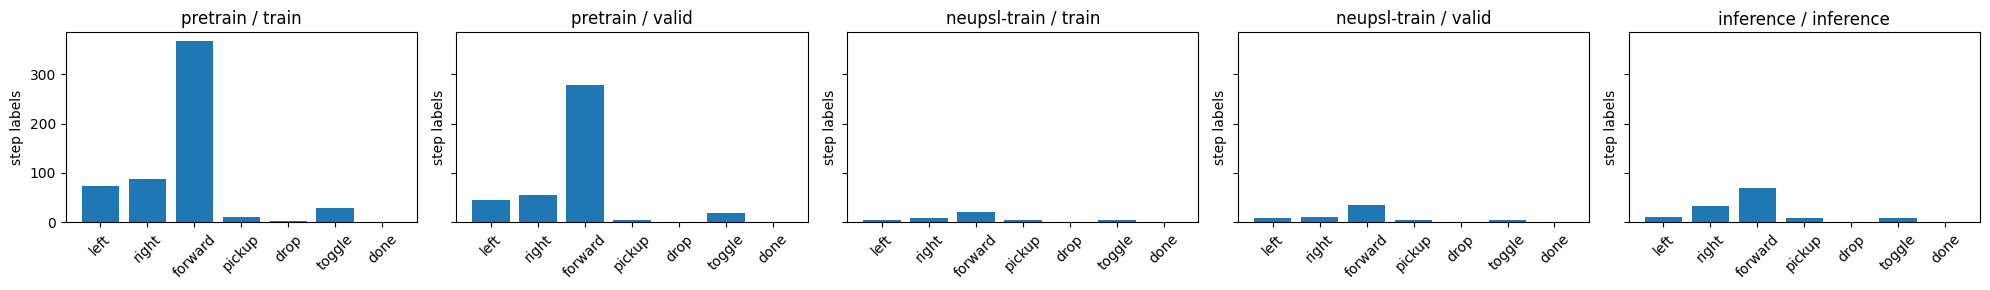

In [84]:
fig, axes = plt.subplots(1, len(summary), figsize=(4 * len(summary), 3), sharey=True)
if len(summary) == 1:
    axes = [axes]
for ax, row in zip(axes, summary):
    labels = list(action_vocab.keys())
    values = [row['actions'].get(label, 0) for label in labels]
    ax.bar(labels, values)
    ax.set_title(f"{row['split']} / {row['partition']}")
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylabel('step labels')
plt.tight_layout()

## Scene Reconstruction

In [85]:
train_rows = all_rows[('pretrain', 'train')]
episodes = defaultdict(list)
for row in train_rows:
    episodes[row['episode_id']].append(row)
def display_episode_score(rows):
    first = rows[0]
    features = first['features']
    score = len(rows)
    if features.get('target_color') != 'blue':
        score += 1000
    if features.get('target_type') != 'box':
        score += 500
    if features.get('target_color') in {'red', 'yellow', 'green'}:
        score += 250
    return score

episode = max(episodes.values(), key=display_episode_score)
episode = sorted(episode, key=lambda row: row['step_index'])
sample = episode[min(2, len(episode) - 1)]
print('episode_id:', sample['episode_id'])
print('env_id:', sample['env_id'])
print('mission:', sample['mission'])
print('steps:', len(episode))
print('sample step:', sample['step_index'], 'next action:', sample['action'])
sample['features']

episode_id: babyai-pickup-v0-00021
env_id: BabyAI-Pickup-v0
mission: pick up a red ball
steps: 97
sample step: 2 next action: left


{'agent_dir': 'west',
 'front_color': 'none',
 'front_state': 'none',
 'front_type': 'empty',
 'hand_color': 'none',
 'hand_type': 'empty',
 'mission_kind': 'pickup',
 'target_color': 'red',
 'target_distance': 'far',
 'target_relation': 'left',
 'target_type': 'ball'}

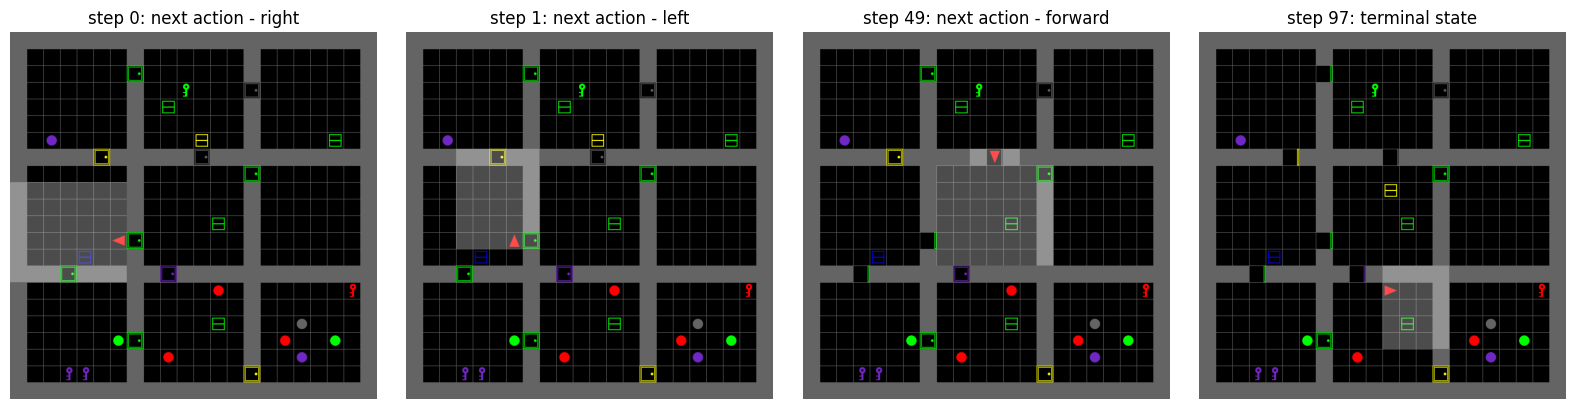

In [86]:
def episode_seed(episode_id):
    match = re.search(r'(\d+)$', episode_id)
    if not match:
        raise ValueError(f'Cannot parse seed from {episode_id}')
    return int(match.group(1))

def render_babyai_episode(row, max_frames=6):
    import gymnasium as gym
    import minigrid  # noqa: F401
    from minigrid.utils.baby_ai_bot import BabyAIBot

    env = gym.make(row['env_id'], render_mode='rgb_array')
    env.reset(seed=episode_seed(row['episode_id']))
    bot = BabyAIBot(env)
    names = {
        int(env.unwrapped.actions.left): 'left',
        int(env.unwrapped.actions.right): 'right',
        int(env.unwrapped.actions.forward): 'forward',
        int(env.unwrapped.actions.pickup): 'pickup',
        int(env.unwrapped.actions.drop): 'drop',
        int(env.unwrapped.actions.toggle): 'toggle',
        int(env.unwrapped.actions.done): 'done',
    }
    frames = []
    actions = []
    last_action = None
    for _ in range(max(len(episode), max_frames)):
        frames.append(env.render())
        action = bot.replan(last_action)
        actions.append(names[int(action)])
        _, _, terminated, truncated, _ = env.step(action)
        last_action = action
        if terminated or truncated:
            frames.append(env.render())
            break
    env.close()
    return frames, actions

def scene_explanation_html(row, picks, rendered_actions):
    features = row['features']
    color_legend = [
        ('red', 'red objects'),
        ('green', 'green objects'),
        ('blue', 'blue objects'),
        ('purple', 'purple objects'),
        ('yellow', 'yellow objects'),
        ('grey', 'walls, floor outlines, or grey objects'),
    ]
    legend = ''.join(
        f'<span style="display:inline-flex;align-items:center;margin-right:12px;margin-bottom:4px">'
        f'<span style="width:12px;height:12px;border-radius:50%;background:{color};border:1px solid #374151;display:inline-block;margin-right:5px"></span>{label}</span>'
        for color, label in color_legend
    )
    frame_notes = []
    for frame_index in picks:
        if frame_index < len(rendered_actions):
            action = rendered_actions[frame_index]
            frame_notes.append(f'<li><b>frame {frame_index}</b>: next action is <code>{action}</code>.</li>')
        else:
            final_action = rendered_actions[-1] if rendered_actions else 'unknown'
            frame_notes.append(f'<li><b>terminal frame {frame_index}</b>: terminal state after final action <code>{final_action}</code>; no next action is predicted here.</li>')
    return f'''
    <div style="margin-top:10px;padding:12px 14px;border:1px solid #d1d5db;border-radius:6px;background:#f9fafb;color:#111827;line-height:1.55">
      <div style="font-weight:700;margin-bottom:6px">Scene Explanation</div>
      <div><b>Mission:</b> {row['mission']}</div>
      <div><b>Target:</b> {features['target_color']} {features['target_type']} · relation <code>{features['target_relation']}</code> · distance <code>{features['target_distance']}</code></div>
      <div><b>Agent state:</b> facing <code>{features['agent_dir']}</code>; front cell is <code>{features['front_color']} {features['front_type']}</code> with state <code>{features['front_state']}</code>; hand is <code>{features['hand_color']} {features['hand_type']}</code>.</div>
      <div style="margin-top:8px"><b>Color legend:</b> {legend}</div>
      <div style="margin-top:6px"><b>Objects:</b> triangular/arrow marker is the agent; colored shapes are BabyAI objects such as balls, boxes, keys, and doors; grey blocks are usually walls or structural cells. For pickup missions, success happens when the agent picks up the target from the front cell; the carried object may no longer appear as a separate grid object in the terminal frame.</div>
      <ul style="margin-top:6px;margin-bottom:0">{''.join(frame_notes)}</ul>
    </div>
    '''

try:
    frames, rendered_actions = render_babyai_episode(sample)
    picks = sorted(set([0, min(1, len(frames)-1), min(len(frames)//2, len(frames)-1), len(frames)-1]))
    fig, axes = plt.subplots(1, len(picks), figsize=(4 * len(picks), 4))
    if len(picks) == 1:
        axes = [axes]
    for ax, frame_index in zip(axes, picks):
        ax.imshow(frames[frame_index])
        label = f'next action - {rendered_actions[frame_index]}' if frame_index < len(rendered_actions) else 'terminal state'
        ax.set_title(f'step {frame_index}: {label}')
        ax.axis('off')
    plt.tight_layout()
    display(HTML(scene_explanation_html(sample, picks, rendered_actions)))
except Exception as exc:
    print('MiniGrid rendering unavailable:', type(exc).__name__, exc)
    print('Symbolic scene:', sample['features'])

## Behavior Timeline

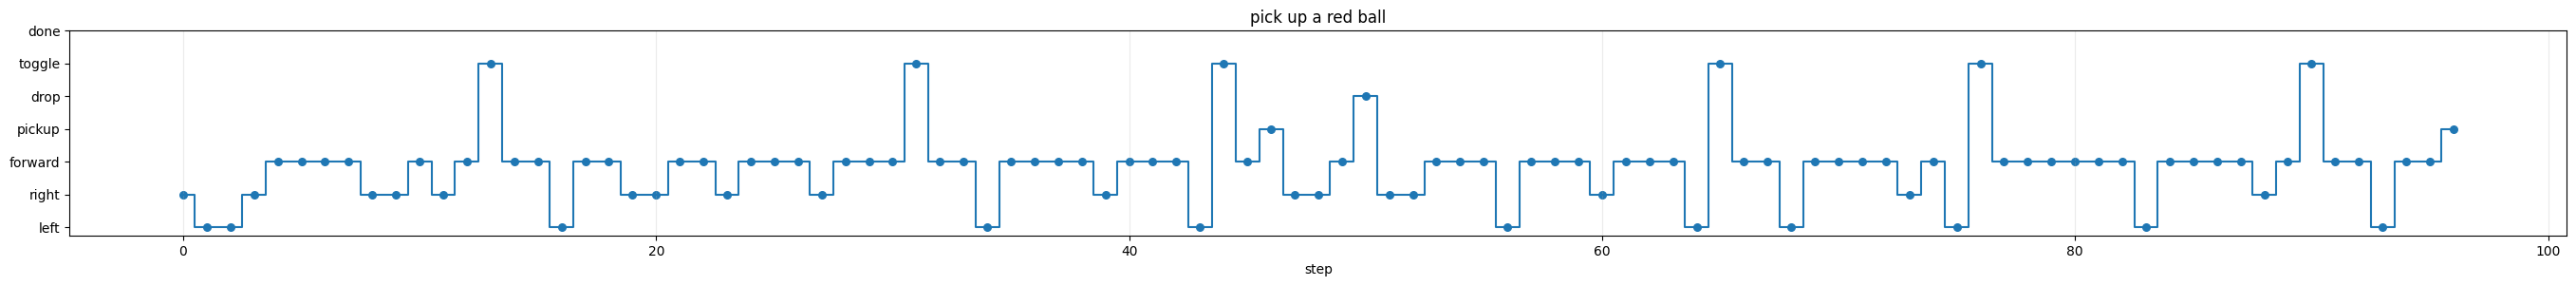

[(0, 'right', 'far', 'left'),
 (1, 'left', 'far', 'behind'),
 (2, 'left', 'far', 'left'),
 (3, 'right', 'far', 'ahead'),
 (4, 'forward', 'far', 'left'),
 (5, 'forward', 'far', 'left'),
 (6, 'forward', 'far', 'left'),
 (7, 'forward', 'far', 'left'),
 (8, 'right', 'far', 'behind'),
 (9, 'right', 'far', 'behind'),
 (10, 'forward', 'far', 'ahead'),
 (11, 'right', 'far', 'right'),
 (12, 'forward', 'far', 'ahead'),
 (13, 'toggle', 'far', 'ahead'),
 (14, 'forward', 'far', 'ahead'),
 (15, 'forward', 'far', 'left'),
 (16, 'left', 'far', 'left'),
 (17, 'forward', 'far', 'ahead'),
 (18, 'forward', 'far', 'ahead'),
 (19, 'right', 'far', 'ahead'),
 (20, 'right', 'far', 'ahead'),
 (21, 'forward', 'far', 'behind'),
 (22, 'forward', 'far', 'behind'),
 (23, 'right', 'far', 'behind'),
 (24, 'forward', 'far', 'right'),
 (25, 'forward', 'far', 'right'),
 (26, 'forward', 'far', 'behind'),
 (27, 'right', 'far', 'behind'),
 (28, 'forward', 'far', 'right'),
 (29, 'forward', 'far', 'right')]

In [87]:
actions = [row['action'] for row in episode]
distances = [row['features']['target_distance'] for row in episode]
relations = [row['features']['target_relation'] for row in episode]
action_to_id = {name: i for i, name in enumerate(action_vocab)}

fig, ax = plt.subplots(figsize=(max(8, len(actions) * 0.35), 2.8))
ax.step(range(len(actions)), [action_to_id[action] for action in actions], where='mid')
ax.scatter(range(len(actions)), [action_to_id[action] for action in actions], s=30)
ax.set_yticks(list(action_to_id.values()), list(action_to_id.keys()))
ax.set_xlabel('step')
ax.set_title(sample['mission'])
ax.grid(axis='x', alpha=0.25)
plt.show()

list(zip(range(len(actions)), actions, distances, relations))[:30]

## Token And Type View

In [88]:
palette = {
    'SPECIAL': ('#f3f4f6', '#374151', '#9ca3af'),
    'MISSION': ('#eff6ff', '#1e3a8a', '#2563eb'),
    'OBS_AGENT': ('#ecfdf5', '#064e3b', '#059669'),
    'OBS_FRONT': ('#fffbeb', '#78350f', '#d97706'),
    'OBS_TARGET': ('#fef2f2', '#7f1d1d', '#dc2626'),
    'OBS_CARRYING': ('#f5f3ff', '#4c1d95', '#7c3aed'),
    'OBS_WORLD': ('#fff7ed', '#7c2d12', '#ea580c'),
    'HISTORY': ('#eef2ff', '#312e81', '#4f46e5'),
}

def token_html(row):
    spans = []
    for token, token_type in zip(row['tokens'], row['types']):
        if token == '[PAD]':
            continue
        bg, fg, border = palette.get(token_type, ('#f9fafb', '#111827', '#6b7280'))
        spans.append(
            f'<span title="{token_type}" style="display:inline-block;margin:2px;padding:4px 8px;border-radius:4px;background:{bg};color:{fg};border-left:4px solid {border};border-top:1px solid #e5e7eb;border-right:1px solid #e5e7eb;border-bottom:1px solid #e5e7eb;font-family:ui-monospace,SFMono-Regular,Menlo,monospace;font-weight:600">{token}</span>'
        )
    return '<div style="line-height:2.2">' + ''.join(spans) + '</div>'

display(HTML(f'<h4>Step {sample["step_index"]}: label = {sample["action"]}</h4>' + token_html(sample)))

## Rule Facts For The Same Episode

invalid facts: [(165, 'drop'), (165, 'pickup'), (165, 'toggle'), (166, 'drop'), (166, 'pickup'), (166, 'toggle'), (167, 'drop'), (167, 'pickup'), (167, 'toggle'), (168, 'drop'), (168, 'pickup'), (168, 'toggle'), (169, 'drop'), (169, 'pickup'), (169, 'toggle'), (170, 'drop'), (170, 'pickup'), (170, 'toggle'), (171, 'drop'), (171, 'pickup'), (171, 'toggle'), (172, 'drop'), (172, 'pickup'), (172, 'toggle'), (173, 'drop'), (173, 'pickup'), (173, 'toggle'), (174, 'drop'), (174, 'pickup'), (174, 'toggle'), (175, 'drop'), (175, 'pickup'), (175, 'toggle'), (176, 'drop'), (176, 'pickup'), (176, 'toggle'), (177, 'drop'), (177, 'pickup'), (177, 'toggle'), (178, 'drop')]
plausible facts: [(178, 'toggle'), (196, 'toggle'), (209, 'toggle'), (230, 'toggle'), (241, 'toggle'), (255, 'toggle'), (261, 'pickup')]


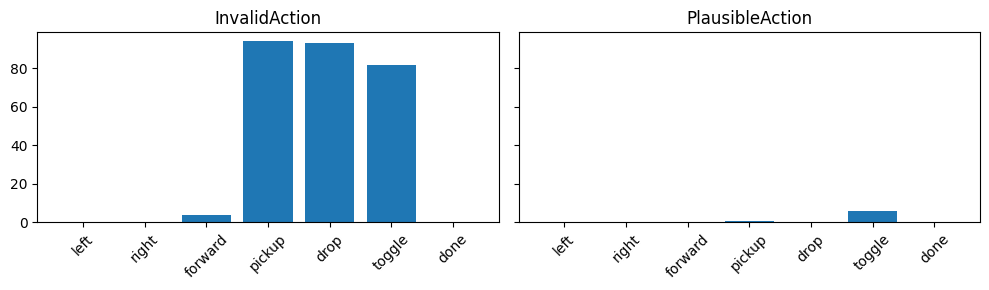

In [89]:
def load_fact_rows(path):
    rows = []
    if path.exists():
        for line in path.read_text().splitlines():
            if line.strip():
                step_id, action = line.split('\t')
                rows.append((int(step_id), action_id_to_name.get(action, action)))
    return rows

split_path = paths['pretrain']
episode_step_ids = {row['step_id'] for row in episode}
invalid = [(sid, action) for sid, action in load_fact_rows(split_path / 'invalid-action-train.txt') if sid in episode_step_ids]
plausible = [(sid, action) for sid, action in load_fact_rows(split_path / 'plausible-action-train.txt') if sid in episode_step_ids]
print('invalid facts:', invalid[:40])
print('plausible facts:', plausible[:40])

fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharey=True)
for ax, title, rows in [(axes[0], 'InvalidAction', invalid), (axes[1], 'PlausibleAction', plausible)]:
    counts = Counter(action for _, action in rows)
    labels = list(action_vocab.keys())
    ax.bar(labels, [counts.get(label, 0) for label in labels])
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()

## Split Projection

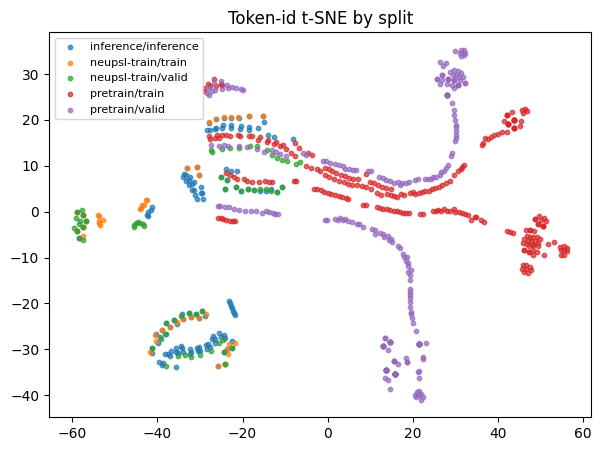

In [90]:
try:
    from sklearn.manifold import TSNE

    rows = []
    labels = []
    for key, key_rows in all_rows.items():
        for row in key_rows[:250]:
            rows.append(np.array(row['token_ids'], dtype=float))
            labels.append('/'.join(key))
    x = np.vstack(rows)
    perplexity = min(30, max(5, len(rows) // 10))
    z = TSNE(n_components=2, init='pca', learning_rate='auto', perplexity=perplexity, random_state=16).fit_transform(x)
    fig, ax = plt.subplots(figsize=(7, 5))
    for label in sorted(set(labels)):
        mask = np.array(labels) == label
        ax.scatter(z[mask, 0], z[mask, 1], s=10, alpha=0.7, label=label)
    ax.legend(fontsize=8)
    ax.set_title('Token-id t-SNE by split')
except Exception as exc:
    print('Projection skipped:', type(exc).__name__, exc)